In [2]:
#Regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import scale
import sklearn.linear_model as lm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [3]:
df1.head(2)

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4


In [4]:
df1.head(2)
df1.info()
df1.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


TV           0
radio        0
newspaper    0
sales        0
dtype: int64

In [5]:
df2.head(2)
df2.info()
df2.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Income     400 non-null    float64
 1   Limit      400 non-null    int64  
 2   Rating     400 non-null    int64  
 3   Cards      400 non-null    int64  
 4   Age        400 non-null    int64  
 5   Education  400 non-null    int64  
 6   Own        400 non-null    object 
 7   Student    400 non-null    object 
 8   Married    400 non-null    object 
 9   Region     400 non-null    object 
 10  Balance    400 non-null    int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 34.5+ KB


Income       0
Limit        0
Rating       0
Cards        0
Age          0
Education    0
Own          0
Student      0
Married      0
Region       0
Balance      0
dtype: int64

In [6]:
df3.head(2)
df3.info()
df3.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 30.6+ KB


mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64

In [7]:
#fill NA with mean
df = pd.DataFrame({'X1': [np.nan, 85, np.nan, 88, 94, 90],
                   'X2': [25, np.nan, 14, 16, 27,np.nan]})

In [8]:
df.head()

,X1,X2
0,NaN,25.0
1,85.0,NaN
2,NaN,14.0
3,88.0,16.0
4,94.0,27.0


In [9]:
print(np.mean(df['X1']))
print(np.mean(df['X2']))

89.25
20.5


In [10]:
df['X1'].fillna((df['X1'].mean()),inplace=True)
df['X2'].fillna((df['X2'].mean()),inplace=True)

In [11]:
df.head()

,X1,X2
0,89.25,25.0
1,85.00,20.5
2,89.25,14.0
3,88.00,16.0
4,94.00,27.0


In [12]:
df2.head()

,Income,Limit,Rating,Cards,Age,Education,Own,Student,Married,Region,Balance
0,14.891,3606,283,2,34,11,No,No,Yes,South,333
1,106.025,6645,483,3,82,15,Yes,Yes,Yes,West,903
2,104.593,7075,514,4,71,11,No,No,No,West,580
3,148.924,9504,681,3,36,11,Yes,No,No,West,964
4,55.882,4897,357,2,68,16,No,No,Yes,South,331


In [13]:
df2.iloc[:,10].value_counts()   ##check Factor [3,6,7,8,9]

Balance
0       90
133      3
1048     3
531      3
333      2
        ..
669      1
68       1
642      1
805      1
966      1
Name: count, Length: 284, dtype: int64

In [14]:
##change datatype
df2['Cards']=df2['Cards'].astype(object)

In [15]:
##convert into dummies
df2['Student2']=df2.Student.map({'No':0,'Yes':1})
df2.head()

,Income,Limit,Rating,Cards,Age,Education,Own,Student,Married,Region,Balance,Student2
0,14.891,3606,283,2,34,11,No,No,Yes,South,333,0
1,106.025,6645,483,3,82,15,Yes,Yes,Yes,West,903,1
2,104.593,7075,514,4,71,11,No,No,No,West,580,0
3,148.924,9504,681,3,36,11,Yes,No,No,West,964,0
4,55.882,4897,357,2,68,16,No,No,Yes,South,331,0


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


Index(['TV', 'radio', 'newspaper', 'sales'], dtype='object')

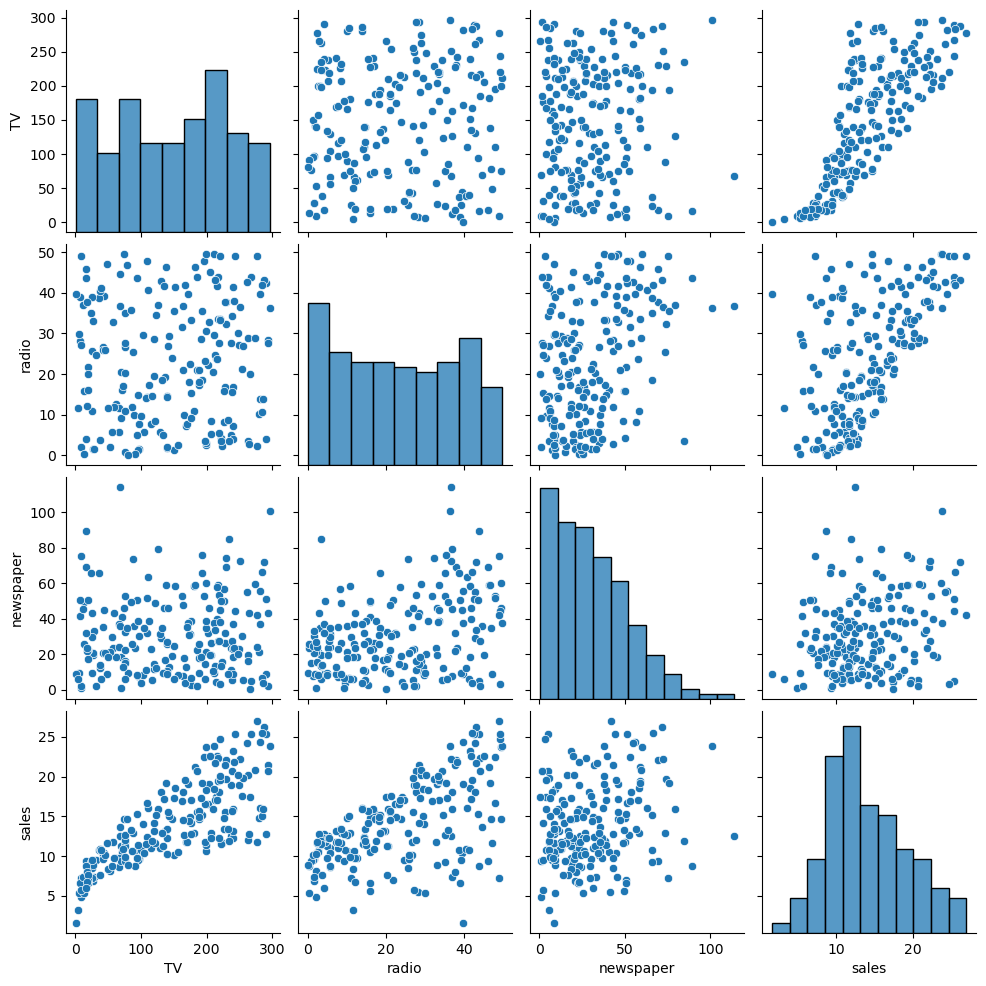

In [16]:
df1=pd.read_csv('Advertising.csv',usecols=[1,2,3,4])   ##usecols=[1,2,3,4]
##Correlation Matrix
df1.corr()

sns.pairplot(df1[['TV', 'radio', 'newspaper', 'sales']])
df1.columns

<Axes: xlabel='TV', ylabel='sales'>

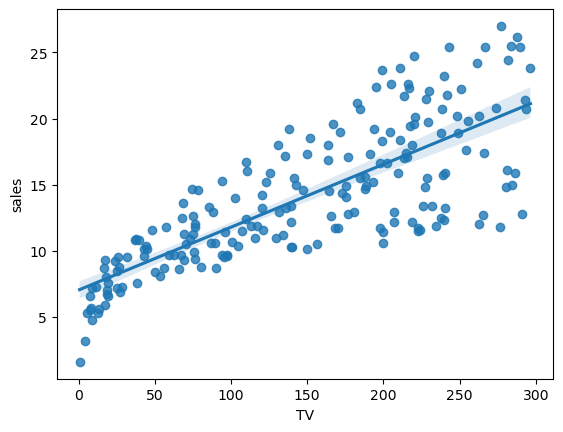

In [17]:
##check ploynomila or not

sns.regplot(data=df1,x='TV',y='sales',order=1)   ##change the order and check

In [18]:
lr = lm.LinearRegression()
X = df1['TV'].values.reshape(-1,1)
Y = df1.sales
lr.fit(X,Y)
print(lr.intercept_)
print(lr.coef_)

7.032593549127694
[0.04753664]


In [19]:
RSS = np.sum((lr.intercept_+lr.coef_*X-Y.values.reshape(-1,1))**2)
RSS

2102.5305831313517

In [20]:
df1['TV2']=df1['TV'].values**2
df1.head()

,TV,radio,newspaper,sales,TV2
0,230.1,37.8,69.2,22.1,52946.01
1,44.5,39.3,45.1,10.4,1980.25
2,17.2,45.9,69.3,9.3,295.84
3,151.5,41.3,58.5,18.5,22952.25
4,180.8,10.8,58.4,12.9,32688.64


In [21]:
lr = lm.LinearRegression()
X = df1['TV2'].values.reshape(-1,1)
Y = df1.sales
lr.fit(X,Y)
print(lr.intercept_)
print(lr.coef_)
RSS = np.sum((lr.intercept_+lr.coef_*X-Y.values.reshape(-1,1))**2)
RSS

9.675705640780887
[0.00015012]


2486.0358052706015

In [22]:
lm_fit1 = smf.ols('sales~TV',df1).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Tue, 19 Mar 2024   Prob (F-statistic):           1.47e-42
Time:                        21:20:12   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.0326      0.458     15.360      0.000       6.130       7.935
TV             0.0475      0.003     17.668      0.000       0.042       0.053
==============================================================================
Omnibus:                        0.531   Durbin-Watson:                   1.935
Prob(Omnibus):                  0.767   Jarque-Bera (JB):                0.669
Skew:                          -0.089   Prob(JB):                        0.716
Kurtosis:                       2.779   Cond. No.                         338.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [23]:
lm_fit1 = smf.ols('sales~TV+TV2',df1).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.615
Method:                 Least Squares   F-statistic:                     160.1
Date:                Tue, 19 Mar 2024   Prob (F-statistic):           5.21e-42
Time:                        21:20:12   Log-Likelihood:                -517.18
No. Observations:                 200   AIC:                             1040.
Df Residuals:                     197   BIC:                             1050.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.1141      0.659      9.275      0.000       4.814       7.414
TV             0.0673      0.011      6.349      0.000       0.046       0.088
TV2        -6.847e-05   3.56e-05     -1.924      0.056      -0.000    1.69e-06
==============================================================================
Omnibus:                        0.681   Durbin-Watson:                   1.967
Prob(Omnibus):                  0.712   Jarque-Bera (JB):                0.770
Skew:                          -0.012   Prob(JB):                        0.681
Kurtosis:                       2.697   Cond. No.                     1.11e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.11e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [24]:
df2.head(1)

,Income,Limit,Rating,Cards,Age,Education,Own,Student,Married,Region,Balance,Student2
0,14.891,3606,283,2,34,11,No,No,Yes,South,333,0


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


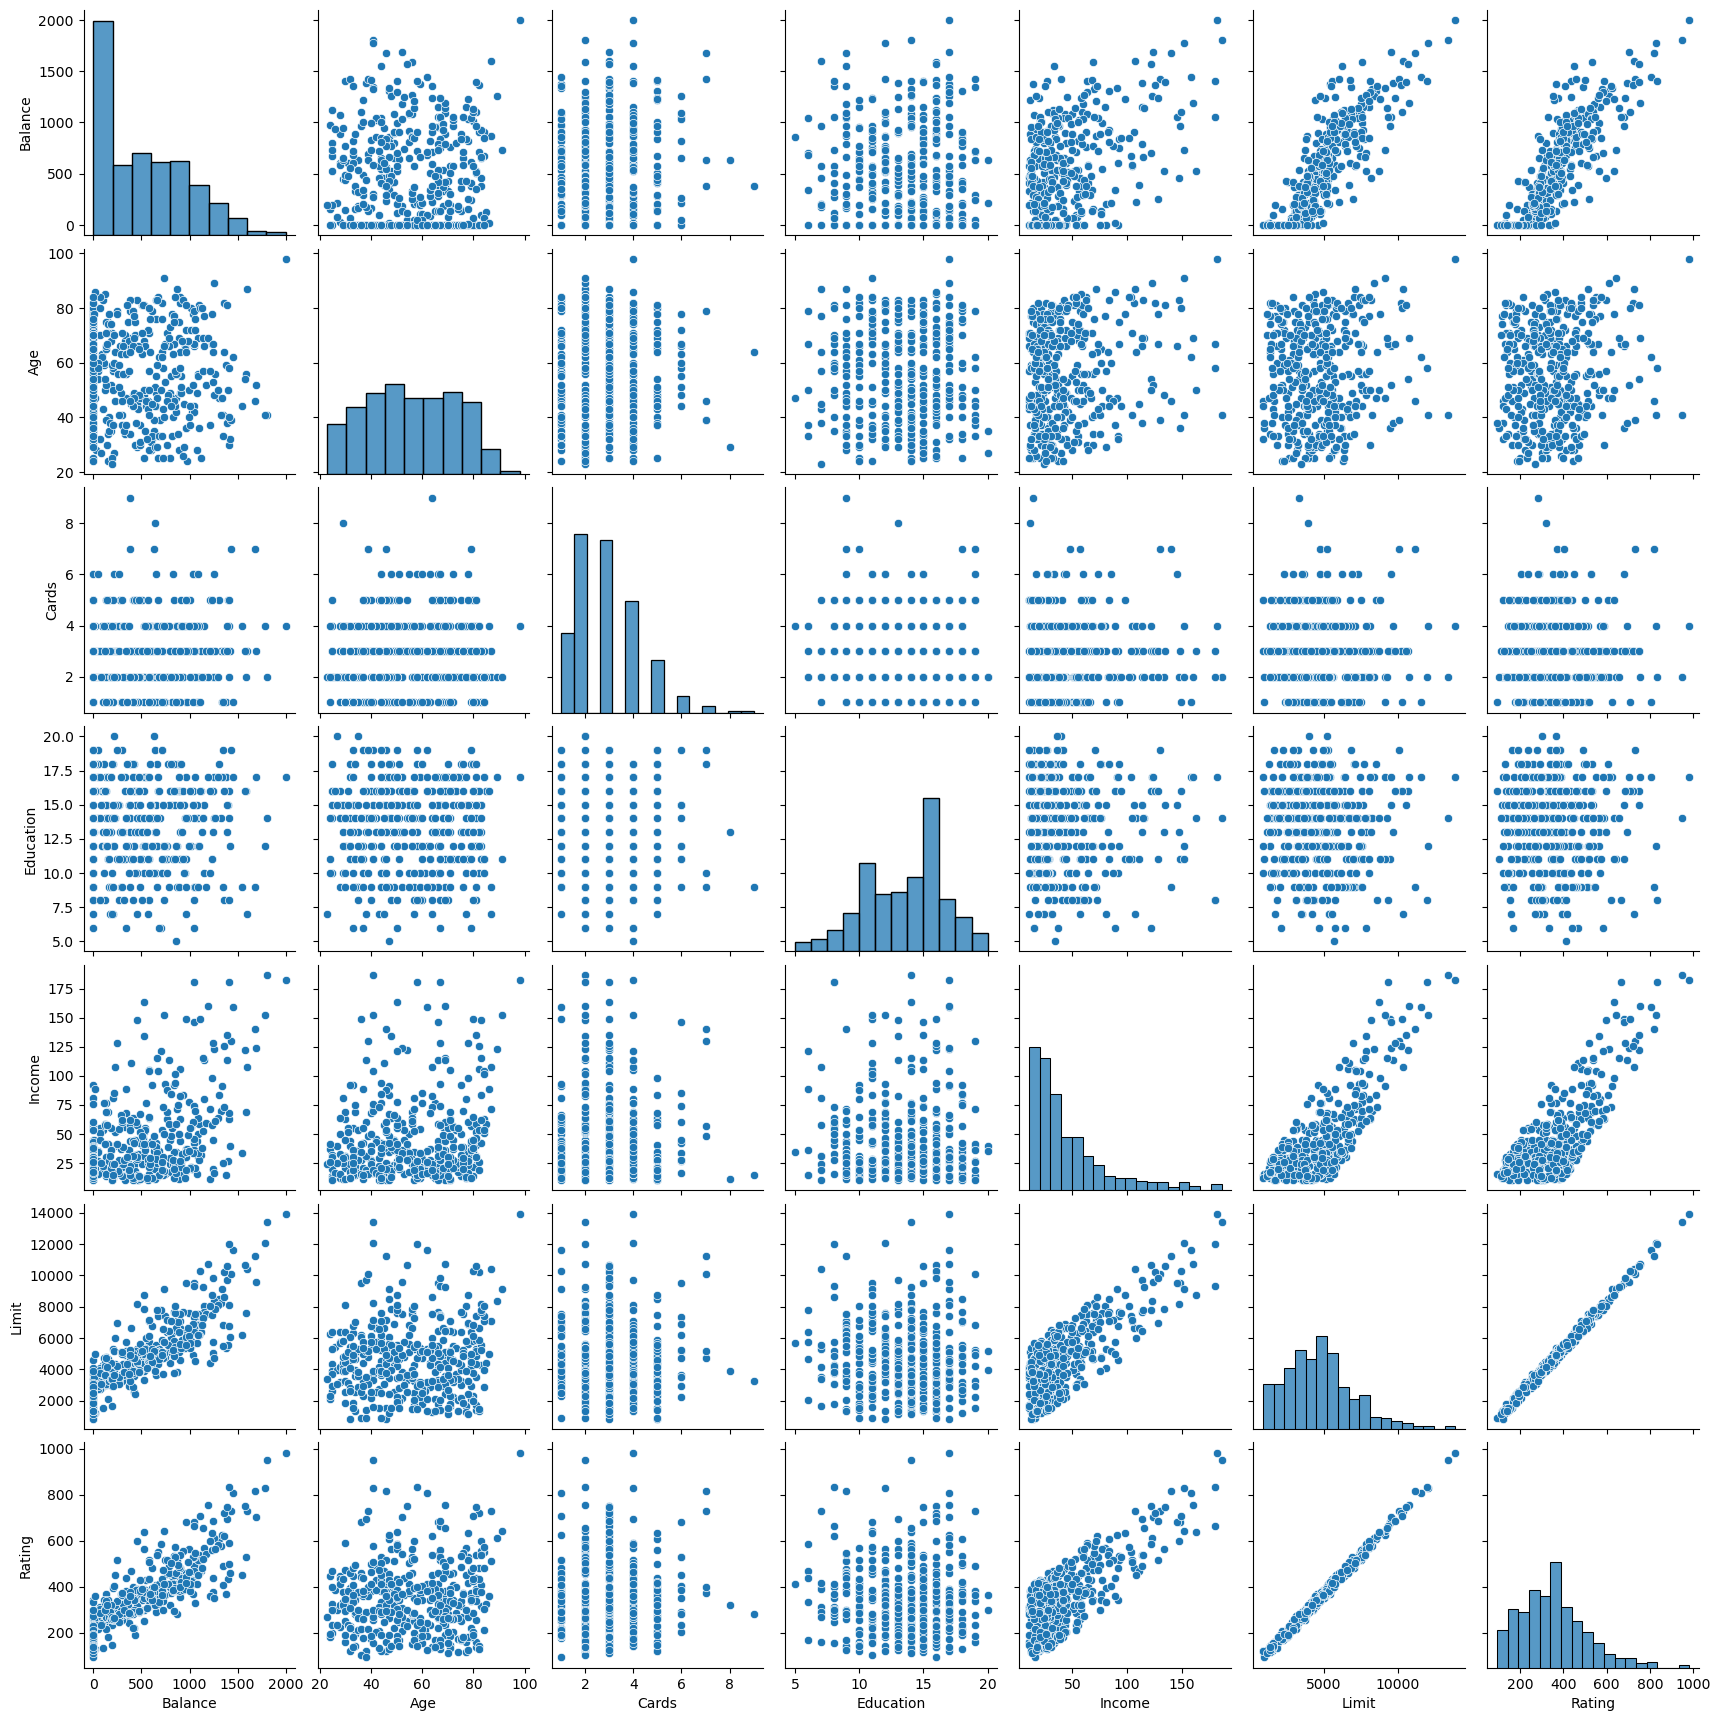

In [25]:
sns.pairplot(df2[['Balance','Age','Cards','Education','Income','Limit','Rating']])

In [26]:
lm_fit = smf.ols('sales~TV',df1).fit()

lm_fit.predict(pd.DataFrame({'TV':[5,10,15]}))

0    7.270277
1    7.507960
2    7.745643
dtype: float64

In [27]:
##Categorical Variables
lm_fit = smf.ols('Balance~Own',df2).fit()
lm_fit.summary().tables[1]
#The average credit card debt for non-ownersmis estimated to be $509.80, 
#whereas owners are estimated to carry $19.73
#in additional debt for a total of $509.80 + $19.73 = $529.53

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,509.8031,33.128,15.389,0.000,444.675,574.931
Own[T.Yes],19.7331,46.051,0.429,0.669,-70.801,110.267


In [28]:
#Do it for Gender

In [29]:
df2['own']=df2['Own'].map({'Yes':-1,'No':1})
df2['own']=df2['own'].astype(object)

In [30]:
lm_fit = smf.ols('Balance~own',df2).fit()
lm_fit.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,529.5362,31.988,16.554,0.000,466.649,592.423
own[T.1],-19.7331,46.051,-0.429,0.669,-110.267,70.801


In [31]:
lm_fit1 = smf.ols('Balance~Region',df2).fit()
lm_fit1.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,531.0000,46.319,11.464,0.000,439.939,622.061
Region[T.South],-12.5025,56.681,-0.221,0.826,-123.935,98.930
Region[T.West],-18.6863,65.021,-0.287,0.774,-146.515,109.142


In [32]:
#East,is $531.00. It is estimated that those in the South will have $18.69 less
#debt than those in the East, and that those in the West will have $12.50
#less debt than those in the East

In [33]:
#one hot encoding

df2["Education"].value_counts()
df2["Education"]=df2["Education"].astype(object)
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Income     400 non-null    float64
 1   Limit      400 non-null    int64  
 2   Rating     400 non-null    int64  
 3   Cards      400 non-null    object 
 4   Age        400 non-null    int64  
 5   Education  400 non-null    object 
 6   Own        400 non-null    object 
 7   Student    400 non-null    object 
 8   Married    400 non-null    object 
 9   Region     400 non-null    object 
 10  Balance    400 non-null    int64  
 11  Student2   400 non-null    int64  
 12  own        400 non-null    object 
dtypes: float64(1), int64(5), object(7)
memory usage: 40.8+ KB


In [34]:
df7= pd.get_dummies(df2, columns = ['Married']) 
df7.head(2)

,Income,Limit,Rating,Cards,Age,Education,Own,Student,Region,Balance,Student2,own,Married_No,Married_Yes
0,14.891,3606,283,2,34,11,No,No,South,333,0,1,False,True
1,106.025,6645,483,3,82,15,Yes,Yes,West,903,1,-1,False,True


In [35]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
label_encoder = LabelEncoder()
df2['Married']=label_encoder.fit_transform(df2['Married'])
df2.head(5)


,Income,Limit,Rating,Cards,Age,Education,Own,Student,Married,Region,Balance,Student2,own
0,14.891,3606,283,2,34,11,No,No,1,South,333,0,1
1,106.025,6645,483,3,82,15,Yes,Yes,1,West,903,1,-1
2,104.593,7075,514,4,71,11,No,No,0,West,580,0,1
3,148.924,9504,681,3,36,11,Yes,No,0,West,964,0,-1
4,55.882,4897,357,2,68,16,No,No,1,South,331,0,1


In [36]:
##VIF-Variance Inflation Factor
est_Age = smf.ols('Age ~ Rating + Limit', df2).fit()
est_Rating = smf.ols('Rating ~ Age + Limit', df2).fit()
est_Limit = smf.ols('Limit ~ Age + Rating', df2).fit()
print(1/(1-est_Age.rsquared))
print(1/(1-est_Rating.rsquared))
print(1/(1-est_Limit.rsquared))

1.0113846860681328
160.66830095856935
160.59287978597942


In [37]:
df4=pd.read_csv('HousingData.csv').dropna()

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
X=df1[['TV','redio','newspaper']]
X = add_constant(X)
#X = add_constant(df4)
#X = X.iloc[:,1:]
vif_df = pd.DataFrame()
vif_df["feature"] = X.columns

# calculating VIF for each feature
vif_df["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]
 
#Print the dataframe with VIF values 
print(vif_df)

    feature         VIF
0     const  686.630694
1      CRIM    1.782836
2        ZN    2.392337
3     INDUS    4.051952
4      CHAS    1.094393
5       NOX    4.707976
6        RM    2.566120
7       AGE    3.180587
8       DIS    4.308653
9       RAD    7.299561
10      TAX    8.902877
11  PTRATIO    2.012261
12        B    1.410486
13    LSTAT    3.648790
14     MEDV    4.293964


In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df1[['TVS', 'radioS', 'newspaperS']]=scaler.fit_transform(df1[['TV', 'radio', 'newspaper']])
df1.head(2)




,TV,radio,newspaper,sales,TV2,TVS,radioS,newspaperS
0,230.1,37.8,69.2,22.1,52946.01,0.969852,0.981522,1.778945
1,44.5,39.3,45.1,10.4,1980.25,-1.197376,1.082808,0.669579


In [40]:
df1=pd.read_csv('Advertising.csv',index_col=0) 
lm_fit1 = smf.ols('sales~TV*radio',df1).fit()
lm_fit1.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,6.7502,0.248,27.233,0.000,6.261,7.239
TV,0.0191,0.002,12.699,0.000,0.016,0.022
radio,0.0289,0.009,3.241,0.001,0.011,0.046
TV:radio,0.0011,5.24e-05,20.727,0.000,0.001,0.001


In [41]:
X=df1[['TV','radio']]


In [42]:
sales_p=lm_fit1.predict(X)    ##2.9211+0.0458*TV+0.1880*radio

In [43]:
import matplotlib.pyplot as plt

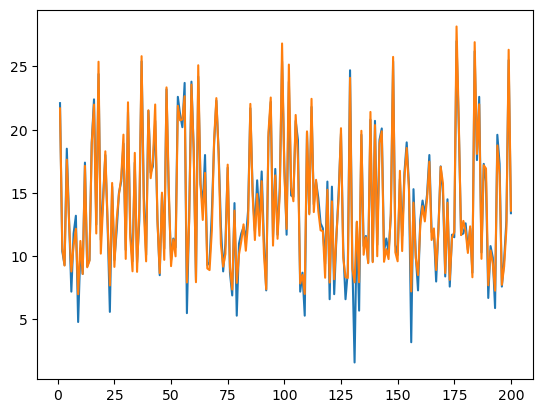

In [44]:
plt.plot(df1['sales'])
plt.plot(sales_p)

In [45]:
mse_1=np.mean((df1["sales"]-sales_p)**2)
mse_1

0.8724169131386358

In [46]:
df3=pd.read_csv('Auto.csv',na_values='?').dropna()

In [47]:
df3.head(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320


In [4]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error 


In [49]:
df3=pd.read_csv('Auto.csv',na_values='?').dropna()
df3.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin', 'name'],
      dtype='object')

In [50]:
fit1=smf.ols('mpg~cylinders+displacement+horsepower+weight+acceleration+year+origin',data=df3).fit()

In [51]:
fit1.summary().tables[1]


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-17.2184,4.644,-3.707,0.000,-26.350,-8.087
cylinders,-0.4934,0.323,-1.526,0.128,-1.129,0.142
displacement,0.0199,0.008,2.647,0.008,0.005,0.035
horsepower,-0.0170,0.014,-1.230,0.220,-0.044,0.010
weight,-0.0065,0.001,-9.929,0.000,-0.008,-0.005
acceleration,0.0806,0.099,0.815,0.415,-0.114,0.275
year,0.7508,0.051,14.729,0.000,0.651,0.851
origin,1.4261,0.278,5.127,0.000,0.879,1.973


In [5]:
df3=pd.read_csv('Auto.csv',na_values='?').dropna()
X=df3[['cylinders','displacement','horsepower','weight','acceleration','origin']]

In [6]:
Y=df3['mpg']

In [54]:
fitR=Ridge(alpha=10)  ##aplpha is lambda
fitR.fit(X,Y)
fitR.coef_
print(pd.Series(fitR.coef_, index=X.columns))

array([-0.25577292,  0.0036742 , -0.05378737, -0.00506366, -0.02547009,
        0.8512297 ])

In [10]:
fitL=Lasso(alpha=10)
fitL.fit(X,Y)
fitL.coef_

array([-0.        , -0.        , -0.        , -0.00750838,  0.        ,
        0.        ])

In [56]:
##Train test split
from sklearn.model_selection import train_test_split

In [58]:
df1.head(2)
X=df1[['TV','radio']]
Y=df1['sales']

In [66]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.20,random_state=123)

In [67]:
df_train=pd.concat([X_train,Y_train],axis=1)

In [71]:
print(df_train.shape)
print(X_test.shape)

(160, 3)
(40, 2)


In [79]:
fit=smf.ols('sales~TV*radio',df_train).fit()
sales_train=fit.predict(X_train)
mse_train=np.mean((Y_train-sales_train)**2)
print(mse_train)

0.9544326122125281


In [80]:
sales_test=fit.predict(X_test)
mse_test=np.mean((Y_test-sales_test)**2)
print(mse_test)

0.5525951053970553


In [102]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
model = lm.LinearRegression()
K=10
kfold = KFold(K,random_state=0,shuffle=True)
mse_cv = cross_val_score(model,X,Y,cv=kfold,scoring='neg_mean_squared_error')
-mse_cv

array([7.19837507, 1.85303566, 1.70195597, 1.19734787, 3.68888369,
       1.77700876, 2.58291862, 2.88479107, 2.88223422, 3.38956917])

In [3]:
##Scaling
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import minmax_scale

In [13]:
scaler = StandardScaler()
df1[['TVS','radioS']]=scaler.fit_transform(df1[['TV','radio']])
df1.head(5)
fit=smf.ols('sales~TVS*radioS',df1).fit()
fit.summary().tables[1]
X=df1[['TVS','radioS']]
salesp=fit.predict(X)
mse=np.mean((df1['sales']-salesp)**2)
print(mse)

0.8724169131386358


In [14]:
##Train test Split
from sklearn.model_selection import train_test_split

In [31]:
X=df1[['TVS','radioS']]
Y=df1['sales']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.20,random_state=123)

df1_train=pd.concat([X_train,Y_train],axis=1)
df1_train.head(2)
fit=smf.ols('sales~TVS*radioS',df1_train).fit()
y_p_train=fit.predict(X_train)
mse_train=np.mean((Y_train-y_p_train)**2)
print(mse_train)
Y_p_test=fit.predict(X_test)
mse_test=np.mean((Y_test-Y_p_test)**2)
print(mse_test)

In [34]:
##Kfold CV
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
import sklearn.linear_model as lm

In [42]:
X=df1[['TVS','radioS']]
Y=df1['sales']
model=lm.LinearRegression()
K=10
kfold=KFold(K,random_state=0,shuffle=True)
mse_cv=cross_val_score(model,X,Y,cv=kfold,scoring='neg_mean_squared_error')
np.mean(-mse_cv)

2.9156120106958077

In [43]:
model =lm.LinearRegression()
K=10
kfold = KFold(K,random_state=0,shuffle=True)
mse_cv = cross_val_score(model,X,Y,cv=kfold,scoring='neg_mean_squared_error')
-mse_cv

array([7.19837507, 1.85303566, 1.70195597, 1.19734787, 3.68888369,
       1.77700876, 2.58291862, 2.88479107, 2.88223422, 3.38956917])

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

In [11]:
df=pd.DataFrame({'Y':[1,0,0,1,1,0,0,1],'X1':[5,6,7,8,9,12,13,14],'X2':[15,63,78,80,92,120,130,140]})

In [12]:
df.head()

,Y,X1,X2
0,1,5,15
1,0,6,63
2,0,7,78
3,1,8,80
4,1,9,92


In [13]:
fit=smf.ols('Y~X1+X2',df).fit()
fit.summary().tables[1]

C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.2919,0.683,0.427,0.687,-1.464,2.048
X1,0.2102,0.209,1.004,0.362,-0.328,0.749
X2,-0.0193,0.017,-1.116,0.315,-0.064,0.025


In [15]:

y_p=fit.predict(df[['X1','X2']])
y_p

0    1.052736
1    0.334344
2    0.254360
3    0.425869
4    0.403922
5    0.492846
6    0.509590
7    0.526334
dtype: float64

In [16]:
import seaborn as sns

In [4]:
df3=pd.read_csv('Auto.csv',na_values='?').dropna()
df3.head(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320


In [16]:
df4 = pd.get_dummies(df3,columns=['origin','cylinders'])

In [17]:
df4.head(2)

,mpg,displacement,horsepower,weight,acceleration,year,name,origin_1,origin_2,origin_3,cylinders_3,cylinders_4,cylinders_5,cylinders_6,cylinders_8
0,18.0,307.0,130.0,3504,12.0,70,chevrolet chevelle malibu,True,False,False,False,False,False,False,True
1,15.0,350.0,165.0,3693,11.5,70,buick skylark 320,True,False,False,False,False,False,False,True


In [50]:
df4 = pd.get_dummies(df3,columns=['origin','cylinders'])
y = df3.mpg
X1 = df3.drop(['mpg','year', 'name','origin','cylinders'], axis=1).astype('float64')
# Define the feature set X.
X = pd.concat([X1, df4[['origin_1','origin_2','origin_3','cylinders_3','cylinders_4','cylinders_5','cylinders_6','cylinders_8']]], axis=1).astype('float64')
X.info()
ridge = Ridge(alpha=2)
ridge.fit(X, y)
print(pd.Series(ridge.coef_, index=X.columns))
lasso = Lasso(alpha=2)
lasso.fit(X, y)
print(pd.Series(Lasso.coef_, index=X.columns))

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 396
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  392 non-null    float64
 1   horsepower    392 non-null    float64
 2   weight        392 non-null    float64
 3   acceleration  392 non-null    float64
 4   origin_1      392 non-null    float64
 5   origin_2      392 non-null    float64
 6   origin_3      392 non-null    float64
 7   cylinders_3   392 non-null    float64
 8   cylinders_4   392 non-null    float64
 9   cylinders_5   392 non-null    float64
 10  cylinders_6   392 non-null    float64
 11  cylinders_8   392 non-null    float64
dtypes: float64(12)
memory usage: 39.8 KB


In [51]:
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV
alphas = 10**np.linspace(10,-2,100)*0.5
ridge = Ridge()
coefs = []

for a in alphas:
    ridge.set_params(alpha=a)
    ridge.fit(X, y)
    coefs.append(ridge.coef_)
    
np.shape(coefs)


(100, 12)

Text(0, 0.5, 'weights')

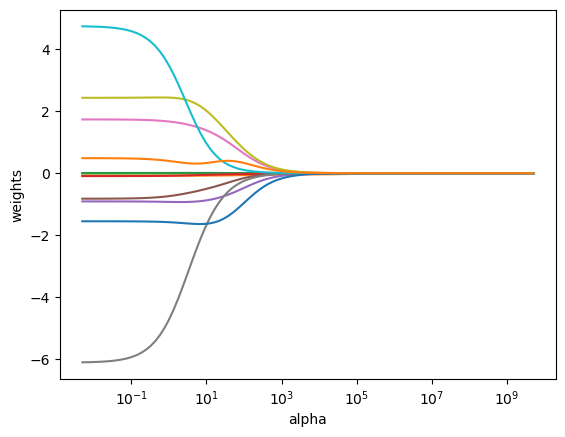

In [52]:
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('weights')

In [53]:
from sklearn.model_selection import train_test_split
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1)

In [60]:
from sklearn.metrics import mean_squared_error
ridge2 = Ridge(alpha=2)
ridge2.fit(X_train, y_train)             # Fit a ridge regression on the training data
pred2 = ridge2.predict(X_test)           # Use this model to predict the test data
print(pd.Series(ridge2.coef_, index=X.columns)) # Print coefficients
print(mean_squared_error(y_test, pred2))        # Calculate the test MSE

displacement   -0.015744
horsepower     -0.039280
weight         -0.003657
acceleration   -0.039525
origin_1       -0.681096
origin_2       -1.693416
origin_3        2.374512
cylinders_3    -2.371776
cylinders_4     0.349738
cylinders_5     4.076098
cylinders_6    -2.292705
cylinders_8     0.238645
dtype: float64
20.067695311994644


In [55]:
##RidgeCV
ridgecv = RidgeCV(alphas=alphas)
ridgecv.fit(X, y)
ridgecv.alpha_    ##best alpha


0.5748784976988678

In [56]:
ridge3 = Ridge(alpha=ridgecv.alpha_)
ridge3.fit(X_train, y_train)             # Fit a ridge regression on the training data
pred3 = ridge3.predict(X_test)           # Use this model to predict the test data
print(pd.Series(ridge3.coef_, index=X.columns)) # Print coefficients
print(mean_squared_error(y_test, pred3))        # Calculate the test MSE

displacement   -0.016734
horsepower     -0.036945
weight         -0.003662
acceleration   -0.056184
origin_1       -0.619975
origin_2       -1.893575
origin_3        2.513550
cylinders_3    -4.705573
cylinders_4     0.341248
cylinders_5     6.576594
cylinders_6    -2.390503
cylinders_8     0.178234
dtype: float64
20.15603755781546


In [57]:
##Lasso CV
lassocv = LassoCV(alphas=alphas)  
lassocv.fit(X_train, y_train)
lassocv.alpha_   #best alpha

0.01155064850041579

In [58]:
lasso3 = Lasso(alpha=lassocv.alpha_)
lasso3.fit(X_train, y_train)             # Fit a lasso regression on the training data
pred3 = lasso3.predict(X_test)           # Use this model to predict the test data
print(pd.Series(lasso3.coef_, index=X.columns)) # Print coefficients
print(mean_squared_error(y_test, pred3))        # Calculate the test MSE

displacement   -0.017443
horsepower     -0.034941
weight         -0.003748
acceleration   -0.053767
origin_1        0.000000
origin_2       -1.293812
origin_3        3.097831
cylinders_3    -5.495661
cylinders_4     0.000000
cylinders_5     7.126659
cylinders_6    -2.595411
cylinders_8     0.000000
dtype: float64
20.23325763323671


In [59]:
X_train

,displacement,horsepower,weight,acceleration,origin_1,origin_2,origin_3,cylinders_3,cylinders_4,cylinders_5,cylinders_6,cylinders_8
31,113.0,95.0,2228.0,14.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
56,91.0,70.0,1955.0,20.5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
258,231.0,105.0,3380.0,15.8,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
33,232.0,100.0,2634.0,13.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
270,134.0,95.0,2515.0,14.8,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
205,97.0,75.0,2155.0,16.4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
257,232.0,90.0,3210.0,17.2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
73,307.0,130.0,4098.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
237,98.0,63.0,2051.0,17.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [4]:

df=pd.read_csv('hakthaon.csv')

In [5]:
from sklearn.model_selection import train_test_split
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [14]:
X=df.drop(['Attrition'],axis=1)
Y=df['Attrition']
Xtrain,Xtest,Ytrain,Ytest=train_test_split(X,Y,test_size=0.20,random_state=123)

In [15]:
df_train=pd.concat([Xtrain,Ytrain],axis=1)
df_test=pd.concat([Xtest,Ytest],axis=1)

In [16]:
df_train.to_csv('train_hk.csv')
df_test.to_csv('test_hk.csv')

In [ ]:
model1=ols('sales~TV',data=df1).fit()
model1.summary()
model2=ols('sales~TV+radio',data=df1).fit()
model2.summary()
X1=df1['TV']
y=df1['sales']
X2=df1[['TV','radio']]
model = lm.LinearRegression()
K=10
kfold = KFold(K,random_state=0,shuffle=True)
mse_cv_1 = cross_val_score(model,X1,y,cv=kfold,scoring='neg_mean_squared_error')
print(-mse_cv_1)
print(np.mean(-mse_cv_1))
mse_cv_2 = cross_val_score(model,X2,y,cv=kfold,scoring='neg_mean_squared_error')
print(-mse_cv_2)
print(np.mean(-mse_cv_2))

In [10]:
df_test.to_csv('customer_test_1.csv')

In [ ]:
#Linearity: The relationship between the independent and dependent variables should be linear. 
#Independence of Errors: The errors (residuals) should be independent of each other, meaning that the error in one observation should not be related to the error in another observation. 
#Homoscedasticity: The variance of the errors should be constant across all levels of the independent variables. 
#Normality of Errors: The errors should be normally distributed. 
#No Multicollinearity: Independent variables should not be highly correlated with each other. 

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
model = lm.LinearRegression()
##Model1
X1=df1[["TV","Radio","Newspaper"]]
y=df1['Sales']
##model2
X2=df1[["TV","Radio"]]
y=df1['Sales']
K=5
kfold = KFold(K,random_state=0,shuffle=True)
mse_cv_1 = cross_val_score(model,X1,Y,cv=kfold,scoring='neg_mean_squared_error')
mse_cv_2 = cross_val_score(model,X2,Y,cv=kfold,scoring='neg_mean_squared_error')
print(np.mean(-mse_cv_1))
print(np.mean(-mse_cv_2))

In [ ]:
ridge = Ridge(alpha=best_alpha)
ridge.fit(X, y)
print(pd.Series(ridge.coef_, index=X.columns))


In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
X1=df1[['TV','Radio','Newspaper']]
y=df1['sales']
X2=df1[['TV','Radio']]
model = lm.LinearRegression()
model1=randomforest()
model2=nn()
K=5
kfold = KFold(K,random_state=0,shuffle=True)
mse_cv_1 = cross_val_score(model1,X1,y,cv=kfold,scoring='neg_mean_squared_error')
print(-mse_cv_1)
print(np.mean(-mse_cv_1))
mse_cv_2 = cross_val_score(model2,X1,y,cv=kfold,scoring='neg_mean_squared_error')
print(-mse_cv_2)
print(np.mean(-mse_cv_2))